# MARL Notebook

### Using Jax for speedy reinforcement learning

Motivation: After developing our environment and training schedule, we ran into time and compute constraints
- Could not run more than ~40 envs on our computer, which for many timesteps took hours

Solution: Use Jax (via MuJoCo Playground environments) to speed things up
- Run in Google collab to get around Jax GPU OS constraints (Jax GPU is meant to run on Linux)

### Background

Jax compiles Python code into optimized machine code (usually via XLA)
- Traces Python functions, builds computation graph, generates machine code for device (GPU in this case)
- Jax can then reuse compiled code, which (combined with GPU speed), makes computations very fast
  - Caveats: Have to make some adjustments (e.g. no inner for loops as they cannot be vectorized by Jax)

Since Jax/JIT traces operations and builds a computation graph, we want to keep things relatively simple to avoid long computations
- Created a new Crazyflie XML without all the collision geoms to speed things up
  - Previously, the physics integrator had to consider all collisions even if we never actually collided with anything
  - We weren't using these geoms anyway, as we end training episodes if drone(s) get to close to the ground or one another ("crash" but no collision)

### Resources

[MuJoCo Playground](https://github.com/google-deepmind/mujoco_playground) with example [Cartpole Balance RL Notebook](https://colab.research.google.com/github/google-deepmind/mujoco_playground/blob/main/learning/notebooks/dm_control_suite.ipynb)


[Brax](https://github.com/google/brax) was used for PPO and as an example to build multi-agent PPO


In [1]:
#@title Install pre-requisites
!pip install mujoco
!pip install mujoco_mjx
!pip install brax
!pip install playground

# Rendering video
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 736.5/736.5 kB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.1/344.1 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.6 MB/s eta 0:00:00


In [2]:
# @title Check if MuJoCo installation was successful and ensure correct config

import distutils.util
import os
import subprocess

if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.'
  )

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco

  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".'
  )

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl
Checking that the installation succeeded:
Installation successful.


In [3]:
# @title Crazyflie Config

from mujoco_playground._src import mjx_env
import mujoco
from mujoco import mjx
import jax
import jax.numpy as jnp
import numpy as np
from ml_collections import config_dict

import mediapy as media
from typing import Any

# Importing Scene from Google Drive (mounted folder)
# Using simplified models without collisions to reduce Jax graph computations
# Don't use collisions anyway, env terminates if drone is near ground
SCENE_PATH_1_DRONE = "/content/drive/MyDrive/assets_mjx/bitcraze_crazyflie_2/scene.xml"
SCENE_PATH_2_DRONES = "/content/drive/MyDrive/assets_mjx/bitcraze_crazyflie_2/scene_multi.xml"

# Adjust XML scene based on number of drones
NUM_DRONES = 2
SCENE_PATH = SCENE_PATH_2_DRONES if NUM_DRONES > 1 else SCENE_PATH_1_DRONE

# Basic info
BASE_HOVER_THRUST = 0.26487
TARGET_POS = jnp.array([0.0, 0.0, 0.5])
QPOS_PER_DRONE = 7  # pos + quat
QVEL_PER_DRONE = 6  # linear vel + angular vel
ACTION_SIZE_PER_DRONE = 4 # Thrust, roll, pitch, yaw

# Random starting state sampled from distribution
TRAINING_POS_RANGE = 2.0
DRONE_SPACING_ALONG_AXIS = 1.0
TRAINING_QUAT_RANGE = np.pi / 8
TRAINING_VEL_RANGE = 0.2
TRAINING_ANG_VEL_RANGE = 0.1

# Out of bounds if N distance further from target compared to starting distance
OUT_OF_BOUNDS_RANGE = 2.0

# Reward and observation constants
TERMINATION_WEIGHT = 1.0
SURVIVAL_WEIGHT = TERMINATION_WEIGHT / 1000
DRONE_PROXIMITY_WEIGHT = 0.01
TARGET_PROXIMITY_WEIGHT = 0.01

DRONE_PROXIMITY_THRESHOLD = 0.2
DRONE_COLLISION_THRESHOLD = 0.05

N_PREV_ACTIONS = 4


# Helper function to convert drone quaternion to rotation matrix
def quat_to_rotation_matrix(q):
    """q is [w, x, y, z]"""
    w, x, y, z = q
    return jnp.array([
        [1 - 2*(y**2 + z**2), 2*(x*y - z*w),     2*(x*z + y*w)],
        [2*(x*y + z*w),       1 - 2*(x**2 + z**2), 2*(y*z - x*w)],
        [2*(x*z - y*w),       2*(y*z + x*w),     1 - 2*(x**2 + y**2)]
    ])


# Evaluation function
def evaluate_policy(env, params, apply_fn, episode_length, seed=0, use_dummy_policy=False):
    jit_reset = jax.jit(env.reset)
    jit_step = jax.jit(env.step)

    def inference_fn(obs_per_agent):
        mean, _ = apply_fn(params, obs_per_agent)
        return mean

    jit_inference = jax.jit(inference_fn)

    # Dummy hover policy action for each drone
    dummy_action_single = jnp.array([BASE_HOVER_THRUST + 0.05, 0.0, 0.0, 0.0])
    dummy_action = jnp.tile(dummy_action_single, (NUM_DRONES,))

    rng = jax.random.PRNGKey(seed)
    rollout = []

    state = jit_reset(rng)
    rollout.append(state)

    for i in range(episode_length):
        if bool(state.done):
            break

        obs = state.obs.reshape((N_AGENTS, PER_AGENT_OBS_DIM))

        if use_dummy_policy:
            action = dummy_action
        else:
            action = jit_inference(obs).reshape((-1,))

        # Env step
        state = jit_step(state, action)
        rollout.append(state)

        # Logs
        obs_np = np.asarray(state.obs)
        pos = obs_np[0:3]
        lin_vel = obs_np[3:6]
        ang_vel = obs_np[6:9]

        num_other_drone_pos = NUM_DRONES * 3
        oldest_action = obs_np[24 + num_other_drone_pos: 28 + num_other_drone_pos]
        action_np = np.asarray(action)

        print(f"\n\nStep {i:04d}, Action {action_np}, Reward {float(state.reward):+.4f}")

        print(f"  \nPartial observation for drone 1")
        print(f"    Pos:          {pos}")
        print(f"    Linear vel:   {lin_vel}")
        print(f"    Angular vel:  {ang_vel}")
        print(f"    Oldest Action in history:  {oldest_action}")

        metrics_np = jax.tree_util.tree_map(
            lambda x: np.asarray(x).item() if np.size(x) == 1 else np.asarray(x),
            state.metrics
        )
        print(f"  \nReward breakdown")
        print(f"    Dist Improvement: {metrics_np.get('reward/distance_improvement', np.nan):+.4f}")
        print(f"    Target Proximity Bonus: {metrics_np.get('reward/proximity_bonus', np.nan):+.4f}")
        print(f"    Survival Bonus: {metrics_np.get('reward/survival_bonus', np.nan):+.4f}")
        print(f"    Drone Proximity Penalty: {metrics_np.get('reward/drone_proximity_penalty', np.nan):+.4f}")
        print(f"    Termination: {metrics_np.get('reward/termination', np.nan):+.4f}")

    # Summary
    rewards = [float(s.reward) for s in rollout]
    print(f"\nTotal steps: {len(rewards)}, Final reward: {rewards[-1]:.4f}")


    # Utility to render target as geom in scene
    print("\nRendering trajectory...")
    target_geom_id = mujoco.mj_name2id(env.mj_model, mujoco.mjtObj.mjOBJ_GEOM, b"target")

    def move_target_geom(scene: mujoco.MjvScene, target_pos: np.ndarray):
        scene.geoms[target_geom_id].pos[:] = target_pos

    modify_target_fn = lambda scene: move_target_geom(scene, TARGET_POS)

    # Collect frames, use track camera from xml scene and update geom pos to target pos
    frames = env.render(
        rollout,
        camera="track",
        modify_scene_fns=[modify_target_fn] * len(rollout),
    )
    media.show_video(frames, fps=1.0 / env.dt)

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'
mujoco_menagerie not found. Downloading...


Cloning mujoco_menagerie: ██████████| 100/100 [00:29<00:00]


Checking out commit 14ceccf557cc47240202f2354d684eca58ff8de4
Successfully downloaded mujoco_menagerie


In [30]:
# @title Crazyflie Env

class CrazyflieEnv(mjx_env.MjxEnv):
    """MJX environment using the Crazyflie drone model."""

    def __init__(self):
        # Define environment configuration (control and sim time steps)
        cfg = config_dict.ConfigDict()
        cfg.ctrl_dt = 0.02    # control step (50Hz)
        cfg.sim_dt = 0.002    # simulation step (500Hz)
        super().__init__(cfg)

        # Load MuJoCo model and convert to MJX
        self._mj_model = mujoco.MjModel.from_xml_path(SCENE_PATH)
        self._mjx_model = mjx.put_model(self._mj_model)

        # Define control/action size as number of actuators (e.g. 8 for 2 drones)
        self._action_size = self._mj_model.nu

        self.target_pos = TARGET_POS

        # If using multiple drones, arrange them in a line (along X axis for now)
        self.dir_x, self.dir_y = 1.0, 0.0
        self.drone_offsets = jnp.linspace(-(NUM_DRONES - 1) / 2, (NUM_DRONES - 1) / 2, NUM_DRONES) * DRONE_SPACING_ALONG_AXIS


    # Expected env properties for Brax PPO training
    @property
    def xml_path(self) -> str:
        return SCENE_PATH

    @property
    def action_size(self) -> int:
        return self.mjx_model.nu

    @property
    def mj_model(self) -> mujoco.MjModel:
        return self._mj_model

    @property
    def mjx_model(self) -> mjx.Model:
        return self._mjx_model


    def reset(self, rng: jax.Array, eval_mode: bool = False) -> mjx_env.State:
        """Vectorized reset for Crazyflie drones."""

        # Random keys
        rng, rng_pos, rng_quat, rng_vel, rng_ang = jax.random.split(rng, 5)


        def enforce_min_spacing(pos, min_dist):
            """Ensure drones don't start too close together."""
            # pos: (N, 3)
            diffs = pos[:, None, :] - pos[None, :, :]      # (N, N, 3)
            dists = jnp.linalg.norm(diffs + jnp.eye(NUM_DRONES)[..., None] * 1e9, axis=-1)

            # Compute how much each pair violates spacing
            violation = jnp.maximum(0.0, min_dist - dists)  # (N, N)

            # Push drones apart along the direction of separation
            direction = diffs / (dists[..., None] + 1e-6)
            adjust = jnp.sum(direction * violation[..., None] * 0.5, axis=1)

            return pos + adjust


        # Random starting positions for drone(s) based on the target pos
        std_pos = TRAINING_POS_RANGE / 2.0
        pos_noise = jax.random.normal(rng_pos, (NUM_DRONES, 3)) * std_pos
        start_pos = self.target_pos + pos_noise
        start_pos = start_pos.at[:, 2].set(jnp.clip(start_pos[:, 2], 0.1, jnp.inf))
        start_pos = enforce_min_spacing(start_pos, DRONE_PROXIMITY_THRESHOLD * 2.0)


        # Drone offset along drones starting axis
        offset_xy = jnp.stack([
            self.drone_offsets * self.dir_x,
            self.drone_offsets * self.dir_y,
            jnp.zeros_like(self.drone_offsets)
        ], axis=1)
        start_pos += offset_xy

        # Random quaternions
        std_angle = TRAINING_QUAT_RANGE / 2.0
        axes = jax.random.normal(rng_quat, (NUM_DRONES, 3))
        axes = axes / jnp.linalg.norm(axes, axis=1, keepdims=True)
        angles = jax.random.normal(rng_quat, (NUM_DRONES,)) * std_angle
        w = jnp.cos(angles)
        quats = jnp.concatenate([w[:, None], axes * jnp.sin(angles)[:, None]], axis=1)

        # Linear and angular velocities
        lin_vel = (TRAINING_VEL_RANGE / 2.0) * jax.random.normal(rng_vel, (NUM_DRONES, 3))
        ang_vel = (TRAINING_ANG_VEL_RANGE / 2.0) * jax.random.normal(rng_ang, (NUM_DRONES, 3))

        # During evaluation, do not start with stateful noise
        if eval_mode:
            eval_height = 0.2
            start_pos = self.target_pos + offset_xy.at[:, 2].set(eval_height)

            lin_vel = jnp.zeros((NUM_DRONES, 3))
            quats = jnp.array([[1., 0., 0., 0.]] * NUM_DRONES)
            ang_vel = jnp.zeros((NUM_DRONES, 3))

        # Assemble qpos/qvel in batch
        qpos = jnp.zeros((NUM_DRONES, QPOS_PER_DRONE), dtype=jnp.float32)
        qpos = qpos.at[:, 0:3].set(start_pos)
        qpos = qpos.at[:, 3:7].set(quats)
        qpos = qpos.reshape(-1)  # flatten for mjx_env

        qvel = jnp.zeros((NUM_DRONES, QVEL_PER_DRONE), dtype=jnp.float32)
        qvel = qvel.at[:, 0:3].set(lin_vel)
        qvel = qvel.at[:, 3:6].set(ang_vel)
        qvel = qvel.reshape(-1)  # flatten for mjx_env

        # Initialize state
        action_history = jnp.zeros((N_PREV_ACTIONS, NUM_DRONES, ACTION_SIZE_PER_DRONE))
        initial_distance = jnp.linalg.norm(start_pos - self.target_pos, axis=1)

        data = mjx_env.init(self._mjx_model, qpos=qpos, qvel=qvel)

        # Metrics
        metrics = {
            "reward/distance_improvement": jnp.zeros(()),
            "reward/proximity_bonus": jnp.zeros(()),
            "reward/survival_bonus": jnp.zeros(()),
            "reward/termination": jnp.zeros(()),
            "reward/drone_proximity_penalty": jnp.zeros(()),
            "reward": jnp.zeros(())
        }

        # State info
        info = {
            "rng": rng,
            "initial_distance": initial_distance,
            "prev_pos": start_pos,
            "action_history": action_history, # (N_prev_actions, N_drones, Action)
        }

        reward = jnp.zeros(())
        done = jnp.zeros(())

        obs = self._get_obs(data, info)

        return mjx_env.State(data=data, obs=obs, reward=reward, done=done, metrics=metrics, info=info)


    def step(self, state: mjx_env.State, action: jax.Array) -> mjx_env.State:
        """Vectorized Crazyflie step for multiple drones with MARL rewards."""

        # Clip flat action (by default done via XML actuators but we are also recording action history)
        action_clipped = action.at[0::4].set(jnp.clip(action[0::4], 0.0, 0.35))   # thrusts
        action_clipped = action_clipped.at[1::4].set(jnp.clip(action[1::4], -1.0, 1.0))  # rolls
        action_clipped = action_clipped.at[2::4].set(jnp.clip(action[2::4], -1.0, 1.0))  # pitches
        action_clipped = action_clipped.at[3::4].set(jnp.clip(action[3::4], -1.0, 1.0))  # yaws

        data = mjx_env.step(self._mjx_model, state.data, action_clipped, n_substeps=self.n_substeps)
        obs = self._get_obs(data, state.info)

        qpos = data.qpos.reshape(NUM_DRONES, QPOS_PER_DRONE)

        # Retrieve stateful info for drone(s)
        prev_pos = state.info["prev_pos"]
        init_dist = state.info["initial_distance"]

        # Dynamic step rewards: Distance to target improvement and target proximity
        pos = qpos[:, :3]
        distance_to_target = jnp.linalg.norm(self.target_pos - pos, axis=1)
        distance_to_target_old = jnp.linalg.norm(self.target_pos - prev_pos, axis=1)
        distance_improvement = distance_to_target_old - distance_to_target

        proximity_bonus = TARGET_PROXIMITY_WEIGHT * (1 - jnp.tanh(distance_to_target))

        # Compute pairwise distances between drones
        diffs = pos[:, None, :] - pos[None, :, :]  # (N, N, 3)
        dists = jnp.linalg.norm(diffs + jnp.eye(NUM_DRONES)[..., None] * 1e9, axis=-1)  # (N, N)

        # Proximity penalty for being closer than threshold to another drone
        proximity_penalty_matrix = jnp.where(
            dists < DRONE_PROXIMITY_THRESHOLD,
            DRONE_PROXIMITY_WEIGHT * (1.0 - dists / DRONE_PROXIMITY_THRESHOLD),
            0.0,
        )
        # Zero out self-distances
        proximity_penalty_matrix = proximity_penalty_matrix * (1.0 - jnp.eye(NUM_DRONES))
        drone_proximity_penalty = jnp.sum(proximity_penalty_matrix, axis=1)

        # Collision check
        collision_matrix = (dists < DRONE_COLLISION_THRESHOLD).astype(jnp.float32)
        collision_any = jnp.clip(jnp.sum(collision_matrix * (1 - jnp.eye(NUM_DRONES)), axis=1), 0, 1)

        # Termination conditions: Crash, stray from target, drone collision
        done_per_drone = (
            (pos[:, 2] < 0.05)
            | (distance_to_target > init_dist + OUT_OF_BOUNDS_RANGE)
            | (collision_any > 0)
        )

        # Reward per drone, 1D jax arrays of shape (NUM_DRONES,)
        reward_per_drone = (
            SURVIVAL_WEIGHT
            + proximity_bonus
            + distance_improvement
            - drone_proximity_penalty
            - done_per_drone.astype(jnp.float32) * TERMINATION_WEIGHT
        )

        # Aggregate reward for the environment
        reward = jnp.sum(reward_per_drone)
        done_all = jnp.any(done_per_drone).astype(jnp.float32)

        # Aggregate per-drone metrics to scalars per environment (match Brax format)
        new_metrics = {
            "reward/distance_improvement": jnp.sum(distance_improvement),
            "reward/proximity_bonus": jnp.sum(proximity_bonus),
            "reward/survival_bonus": SURVIVAL_WEIGHT * NUM_DRONES,
            "reward/termination": - done_all * TERMINATION_WEIGHT,
            "reward/drone_proximity_penalty": - jnp.sum(drone_proximity_penalty),
            "reward": reward,
        }

        # Reshape flat action back to per drone, update action history
        actions_per_drone = action_clipped.reshape(NUM_DRONES, ACTION_SIZE_PER_DRONE)
        new_action_history = jnp.concatenate(
            [state.info["action_history"][1:],
            actions_per_drone[jnp.newaxis, ...]],
            axis=0
        )

        # Update info (prev pos and action history)
        new_info = dict(state.info)
        new_info["prev_pos"] = pos
        new_info["action_history"] = new_action_history

        return mjx_env.State(
            data=data,
            obs=obs,
            reward=reward,
            done=done_all,
            metrics=new_metrics,
            info=new_info,
        )


    # Obs per-drone: pos + vel + angular velocity + Rotation mat + relative pos (body) + vel (body) + Act history
    # Per-drone: 3 + 3 + 3 + 9 + 3 + 3 + history_length * 4
    def _get_obs(self, data, info):
        qpos = data.qpos.reshape(NUM_DRONES, QPOS_PER_DRONE)
        qvel = data.qvel.reshape(NUM_DRONES, QVEL_PER_DRONE)

        # Convert drone(s) quat to rotation matrix
        quat = qpos[:, 3:7]
        rot_mats = jax.vmap(quat_to_rotation_matrix)(quat) # (N, 3, 3)

        # Get relative position to target in drone body coordinates (normalize by initial dist)
        initial_dist = info["initial_distance"][:, None] # (NUM_DRONES,) --> (N, 1)
        pos = qpos[:, :3]
        pos_error = self.target_pos - pos # (N, 3)
        pos_error_norm = pos_error / (initial_dist + 1e-9)
        rel_pos_body = jnp.einsum('nij,nj->ni', rot_mats.transpose((0, 2, 1)), pos_error_norm)

        # Get linear velocity in drone body coordinates
        vel = qvel[:, :3]
        linear_vel_body = jnp.einsum('nij,nj->ni', rot_mats.transpose((0, 2, 1)), vel)

        ang_vel = qvel[:, 3:6]

        # Compute relative positions to other drones in body coordinates
        # Currently includes self-relative pos (always [0, 0, 0]) - maybe remove with mask or similar
        rel_pos_all = pos[:, None, :] - pos[None, :, :]  # (N, N, 3)
        rel_pos_all_body = jnp.einsum('nij,nkj->nki', rot_mats.transpose((0, 2, 1)), rel_pos_all)  # (N, N, 3)
        rel_pos_all_body_flat = rel_pos_all_body.reshape(NUM_DRONES, -1)

        # Base state (per drone)
        core = jnp.concatenate(
            [
                pos, vel, ang_vel, rot_mats.reshape(NUM_DRONES, -1),
                rel_pos_body, linear_vel_body, rel_pos_all_body_flat
            ],
            axis=1,
        )

        # Append action history per drone
        def obs_for_drone(i):
            act_hist_flat = info["action_history"][:, i, :].reshape(-1)
            return jnp.concatenate([core[i], act_hist_flat])

        obs_per_drone = jax.vmap(obs_for_drone)(jnp.arange(NUM_DRONES))

        # Final flattened observation
        return obs_per_drone.reshape(-1)

In [ ]:
# @title Crazyflie Rollout Example (upwards hover dummy policy)
env = CrazyflieEnv()

rollout = evaluate_policy(
    env=env,
    params=None,
    apply_fn=None,
    episode_length=500,
    seed=42,
    use_dummy_policy=True
)



Step 0000, Action [0.31487 0.      0.      0.      0.31487 0.      0.      0.     ], Reward +0.0072
  
Partial observation for drone 1
    Pos:          [0.10536222 0.796171   0.09709126]
    Linear vel:   [-0.01198793 -0.15057793 -0.12737767]
    Angular vel:  [0.03274025 0.00869081 0.08009031]
    Oldest Action in history:  [0. 0. 0. 0.]
  
Reward breakdown
    Dist Improvement: +0.0010
    Target Proximity Bonus: +0.0042
    Survival Bonus: +0.0020
    Drone Proximity Penalty: -0.0000
    Termination: -0.0000


Step 0001, Action [0.31487 0.      0.      0.      0.31487 0.      0.      0.     ], Reward +0.0082
  
Partial observation for drone 1
    Pos:          [0.10528462 0.7930199  0.09490463]
    Linear vel:   [ 0.00422926 -0.16455467 -0.0912914 ]
    Angular vel:  [0.0327346 0.008709  0.0800886]
    Oldest Action in history:  [0. 0. 0. 0.]
  
Reward breakdown
    Dist Improvement: +0.0019
    Target Proximity Bonus: +0.0043
    Survival Bonus: +0.0020
    Drone Proximity Penal

100%|██████████| 99/99 [00:00<00:00, 319.88it/s]


This browser does not support the video tag.


# Initial Jax Testing: Single-Agent PPO Using Brax

The following can be run with one drone or multiple (just 2 at the moment). If one drone, it is standard PPO, with 2 drones it is still "single agent" since the actor and critic see all observations and output actions for both drones, instead of drone actors we have a "dispatcher" controlling both.

## PPO Training

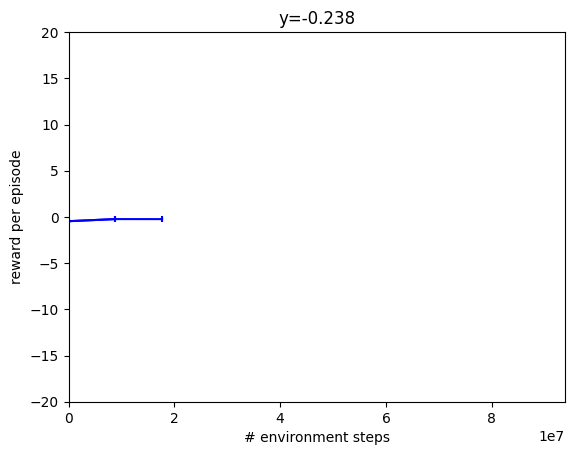

KeyboardInterrupt: 

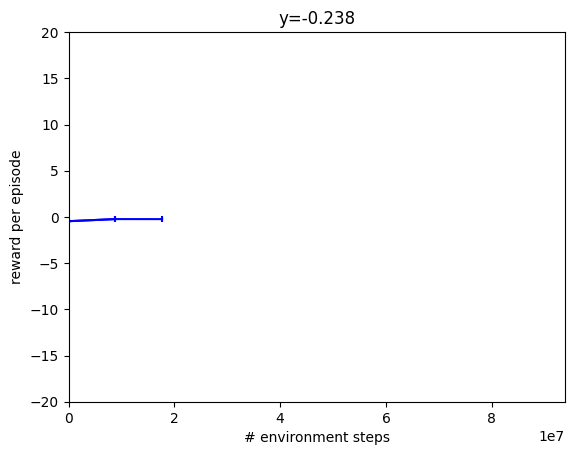

In [ ]:
# test
from datetime import datetime
import functools
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import mediapy as media
import jax
import jax.numpy as jnp
import numpy as np
from ml_collections import config_dict

from mujoco_playground import wrapper
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from mujoco_playground.config import dm_control_suite_params


# Progress plots
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]
def progress(num_steps, metrics):
    clear_output(wait=True)
    times.append(datetime.now())
    x_data.append(num_steps)
    y_data.append(metrics["eval/episode_reward"])
    y_dataerr.append(metrics["eval/episode_reward_std"])

    plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
    plt.ylim([-20, 20])
    plt.xlabel("# environment steps")
    plt.ylabel("reward per episode")
    plt.title(f"y={y_data[-1]:.3f}")
    plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")
    display(plt.gcf())

# Anneal LR
def linear_annealing_lr(init_lr, final_lr, num_timesteps):
    def schedule(step):
        progress = step / num_timesteps
        return init_lr + progress * (final_lr - init_lr)
    return schedule

# PPO training parameters
ppo_params = config_dict.create(
    num_timesteps=75_000_000,
    num_evals=10,
    episode_length=1500,
    normalize_observations=True,
    action_repeat=1,
    unroll_length=30,
    num_minibatches=32,
    num_updates_per_batch=16,
    discounting=0.995,
    learning_rate=linear_annealing_lr(3e-3, 3e-4,  75_000_000),
    entropy_cost=1e-3,
    num_envs=2048,
    batch_size=1024,
)

ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
    del ppo_training_params["network_factory"]
    network_factory = functools.partial(
        ppo_networks.make_ppo_networks,
        **ppo_params.network_factory
    )

train_fn = functools.partial(
    ppo.train,
    **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress
)

# Create environment
env = CrazyflieEnv()

# Train PPO agent - make_inference_fn is our policy function, params are network parameters, metrics are training stats
# Wrap env for training to match Brax format (e.g. add device and env dimensions to obs)
make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

## PPO Test Rollout

In [ ]:
env = CrazyflieEnv()

rollout = evaluate_policy(
    env=env,
    params=params,
    apply_fn=make_inference_fn(params, deterministic=True),
    episode_length=ppo_params["episode_length"],
    seed=42,
    use_dummy_policy=False
)

# Custom Multi-Agent PPO (MAPPO) for Multiple Agents

True multi-agent RL: actors see & act on their own observations (+ relative pos to other drones), critic sees global observation and computes a global reward. The actors share parameters/policy (the same policy examines each drone's observations and outputs an action for each drone).

## MAPPO Training setup (also run this cell if loading a model)

In [19]:
import functools
from typing import Any, Callable, Tuple

import jax
import jax.numpy as jnp
import numpy as np
import optax
import flax.linen as nn
from flax.training.train_state import TrainState
from dataclasses import dataclass
from datetime import datetime
from IPython.display import clear_output
import matplotlib.pyplot as plt

# ---------------------------
# Hyperparameters / settings
# ---------------------------
NUM_ENVS = 2048
NUM_UPDATES = 1000 # Total #updates during training (analogous to total steps)
ROLLOUT_STEPS = 128

NUM_EPOCHS = 2
NUM_MINIBATCHES = 16
MINI_BATCH_SIZE = NUM_ENVS * ROLLOUT_STEPS // NUM_MINIBATCHES

EPISODE_LENGTH = 1500

# Discounting
GAMMA = 0.995
GAE_LAMBDA = 0.95

# Annealing LR
LR = 3e-3
LR_FINAL = 3e-3 * 0.25

CLIP_EPS = 0.2
ENTROPY_COEF = 1e-3
VF_COEF = 0.5
MAX_GRAD_NORM = 0.5
KL_THRESHOLD = 0.05

SEED = 42
POLICY_HIDDEN = [128 * NUM_DRONES, 128 * NUM_DRONES]
VF_HIDDEN = [128 * NUM_DRONES, 128 * NUM_DRONES]


# ---------------------------
# Models (Flax)
# ---------------------------

class MLP(nn.Module):
    hidden_sizes: Tuple[int, ...]
    activate_final: bool = False

    @nn.compact
    def __call__(self, x):
        for i, h in enumerate(self.hidden_sizes):
            x = nn.relu(nn.Dense(h)(x))
        if self.activate_final:
            x = nn.relu(x)
        return x

class Actor(nn.Module):
    """Per-agent Gaussian policy: state --> mean, log(std)"""
    hidden_sizes: Tuple[int, ...]
    action_dim: int

    @nn.compact
    def __call__(self, x):
        # x: (..., obs_dim_per_agent)
        h = MLP(self.hidden_sizes)(x)

        # Layers for mean and log_std weights & biases
        mean = nn.Dense(self.action_dim)(h)
        log_std = nn.Dense(self.action_dim)(h)

        # Ensure numerically reasonable range for log_std
        log_std = jnp.clip(log_std, -20.0, 2.0)

        return mean, log_std

@functools.partial(jax.jit, static_argnums=(1,))
def actor_forward(params, apply_fn, per_agent_obs):
    """Decentralized (per-agent) policy update, sharing parameters across agents."""
    # per_agent_obs: (batch, n_agents, per_agent_obs_dim)
    # Compute mean/log_std for each agent independently.
    B, A, D = per_agent_obs.shape
    flat = per_agent_obs.reshape((B * A, D))

    mean, log_std = apply_fn(params, flat)  # shapes (B*A, action_dim)
    mean = mean.reshape((B, A, -1))
    log_std = log_std.reshape((B, A, -1))

    return mean, log_std


class CentralizedCritic(nn.Module):
    """Takes global joint observation (all agents concatenated) -> scalar value."""
    hidden_sizes: Tuple[int, ...]
    @nn.compact
    def __call__(self, x):
        h = MLP(self.hidden_sizes)(x)
        v = nn.Dense(1)(h)
        return jnp.squeeze(v, -1)  # (batch,)

@functools.partial(jax.jit, static_argnums=(1,))
def critic_forward(params, apply_fn, global_obs):
    """Centralized critic update, sees all observations and computes centralized reward."""
    # global_obs: (batch, per_env_obs_dim)
    return apply_fn(params, global_obs)  # (batch,)

# ---------------------------
# TrainState wrappers, define as pytree
# ---------------------------

# https://flax.readthedocs.io/en/latest/_modules/flax/training/train_state.html
@jax.tree_util.register_pytree_node_class
@dataclass
class PPOTrainState:
    policy_state: TrainState
    value_state: TrainState
    env_steps: jnp.ndarray  # shape (NUM_ENVS,), int32
    ep_returns: jnp.ndarray  # shape (NUM_ENVS,)

    def tree_flatten(self):
        children = (self.policy_state, self.value_state, self.env_steps, self.ep_returns)
        return children, None

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        return cls(*children)

# ---------------------------
# Helpers
# ---------------------------

def gaussian_log_prob(mean, log_std, action):
    # mean, log_std, action shapes: (..., action_dim)
    var = jnp.exp(2.0 * log_std)
    logp = -0.5 * (((action - mean) ** 2) / (var + 1e-8) + 2 * log_std + jnp.log(2 * jnp.pi))
    return jnp.sum(logp, axis=-1)  # sum over action dim


# Safe scalar clipping (for jax.grad stability)
def clip_by_global_norm(updates, max_norm):
    g_norm = jnp.sqrt(sum([jnp.sum(jnp.square(p)) for p in jax.tree_util.tree_leaves(updates)]))
    trigger = g_norm < max_norm
    coef = jnp.where(trigger, 1.0, max_norm / (g_norm + 1e-6))
    return jax.tree_util.tree_map(lambda p: p * coef, updates)

# ---------------------------
# Vectorized environment functions
# ---------------------------

# Create env and infer shapes
def make_env_and_infer():
    env = CrazyflieEnv()
    key = jax.random.PRNGKey(0)
    st = env.reset(key)
    obs = st.obs

    # obs is flattened across drones: shape (per_env_obs_dim,)
    per_env_obs_dim = obs.shape[0]
    action_dim = env.action_size  # total action size (flat, across drones)

    # Per agent obs dimension
    per_agent_obs_dim = per_env_obs_dim // NUM_DRONES

    return env, per_env_obs_dim, per_agent_obs_dim, NUM_DRONES, action_dim, ACTION_SIZE_PER_DRONE

env, PER_ENV_OBS_DIM, PER_AGENT_OBS_DIM, N_AGENTS, ACTION_DIM, PER_AGENT_ACTION_DIM = make_env_and_infer()

# Vectorized reset and step across num_envs
@functools.partial(jax.jit, static_argnums=0)
def vec_reset(env, rngs):
    """Reset env(s) based on rng key(s)"""
    return jax.vmap(lambda k: env.reset(k))(rngs)

@functools.partial(jax.jit, static_argnums=0)
def vec_step(env, states, actions):
    """
    Step env(s)

    Parameters
    -----------
    states: pytree of length num_envs
    actions: flattened (num_envs, action_dim)

    """
    return jax.vmap(lambda s, a: env.step(s, a))(states, actions)



# ---------------------------
# Training (also handles PPO loss and rollout)
# ---------------------------

def create_train_state(rng, num_updates):
    # initialize actor and critic parameters
    rng1, rng2 = jax.random.split(rng)
    # Policy params: we expect to pass per-agent obs shape (PER_AGENT_OBS_DIM)
    actor_module = Actor(hidden_sizes=tuple(POLICY_HIDDEN), action_dim=PER_AGENT_ACTION_DIM)
    critic_module = CentralizedCritic(hidden_sizes=tuple(VF_HIDDEN))

    dummy_agent_obs = jnp.zeros((1, PER_AGENT_OBS_DIM))
    dummy_global_obs = jnp.zeros((1, PER_ENV_OBS_DIM))

    actor_params = actor_module.init(rng1, dummy_agent_obs)
    critic_params = critic_module.init(rng2, dummy_global_obs)

    # Anneal LR
    lr_schedule = optax.linear_schedule(
        init_value=LR,
        end_value=LR_FINAL,
        transition_steps=num_updates
    )

    policy_tx = optax.chain(
        optax.clip_by_global_norm(MAX_GRAD_NORM),
        optax.adam(lr_schedule),
    )
    value_tx = optax.chain(
        optax.clip_by_global_norm(MAX_GRAD_NORM),
        optax.adam(lr_schedule),
    )

    policy_state = TrainState.create(apply_fn=actor_module.apply, params=actor_params, tx=policy_tx)
    value_state = TrainState.create(apply_fn=critic_module.apply, params=critic_params, tx=value_tx)
    env_steps = jnp.zeros((NUM_ENVS,), dtype=jnp.int32)
    ep_returns = jnp.zeros((NUM_ENVS,), dtype=jnp.float32)

    return PPOTrainState(
        policy_state=policy_state,
        value_state=value_state,
        env_steps=env_steps,
        ep_returns=ep_returns
    ), actor_module, critic_module


## MAPPO Training

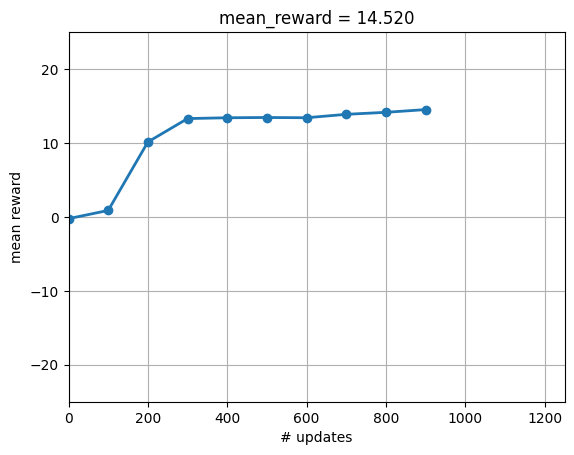

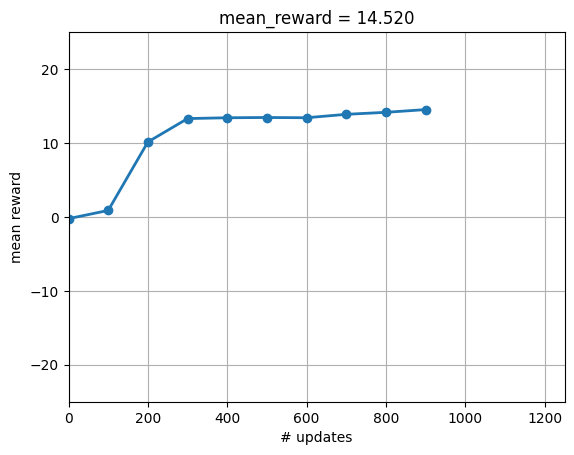

In [42]:
def train(num_updates=NUM_UPDATES, progress_fn=lambda *args: None):
    rng = jax.random.PRNGKey(SEED)
    rng, init_rng = jax.random.split(rng)

    # Create parameters + optimizer state
    train_state, actor_module, critic_module = create_train_state(init_rng, num_updates)

    # Initialize vectorized environments
    rng, *sub = jax.random.split(rng, NUM_ENVS + 1)
    env_states = vec_reset(env, jnp.stack(sub))

    # --------------------------------------------------------------
    # 1. Define GAE function
    # --------------------------------------------------------------
    @jax.jit
    def gae_advantages(rewards, values, dones, gamma=GAMMA, lam=GAE_LAMBDA):
        """
        rewards: (T, N)
        values:  (T+1, N) --> Extra last value for bootstrap
        dones:   (T, N)   --> 0/1 floats or bools

        returns:
          advantages: (T, N)
          returns:    (T, N)  == advantages + values[:-1]
        """

        # Reverse sequences for backward scan
        rewards_r = rewards[::-1]
        values_t_r = values[:-1][::-1]   # values[t] reversed
        values_tp1_r = values[1:][::-1]  # values[t+1] reversed
        dones_r = dones[::-1]

        init = jnp.zeros_like(values[0])  # shape (N,)

        def scan_fn(carry, elems):
            # Carry: advantage_{t+1} (in reversed time)
            r, v, vnext, done = elems
            nonterminal = 1.0 - done
            delta = r + gamma * vnext * nonterminal - v
            adv = delta + gamma * lam * nonterminal * carry
            return adv, adv  # new carry, output advantage

        # Scan over reversed timesteps
        _, advs_rev = jax.lax.scan(
            scan_fn,
            init,
            (rewards_r, values_t_r, values_tp1_r, dones_r),
        )

        # Reverse back to original time order
        advantages = advs_rev[::-1]
        returns = advantages + values[:-1]

        return advantages, returns


    # --------------------------------------------------------------
    # 2. Define Rollout step: Using Jax scan & carry, no rollout buffer
    # --------------------------------------------------------------
    def rollout_step(carry, _):
        # Read carry from previous state, create keys
        env_states, train_state, rng = carry
        rng, step_key, reset_key = jax.random.split(rng, 3)

        # Read observation
        obs = env_states.obs
        per_agent_obs = obs.reshape((NUM_ENVS, N_AGENTS, PER_AGENT_OBS_DIM))

        # Sample action from the policy using per-agent (decentralized) obs
        mean, log_std = actor_forward(
            train_state.policy_state.params,
            train_state.policy_state.apply_fn,
            per_agent_obs,
        )
        eps = jax.random.normal(step_key, mean.shape)
        actions_per_agent = mean + jnp.exp(log_std) * eps
        log_prob_per_agent = gaussian_log_prob(mean, log_std, actions_per_agent)
        log_prob_per_env = jnp.sum(log_prob_per_agent, axis=1)

        # Compute value of current state using global (centralized) obs
        values = critic_forward(
            train_state.value_state.params,
            train_state.value_state.apply_fn,
            obs,
        )

        # Step the environment with flat action array
        flat_actions = actions_per_agent.reshape((NUM_ENVS, -1))
        next_env_states = vec_step(env, env_states, flat_actions)

        # Detect episode termination: terminate episode if any one drone terminates
        env_steps = train_state.env_steps + 1
        truncated = env_steps >= EPISODE_LENGTH
        done = jnp.logical_or(next_env_states.done.reshape(NUM_ENVS), truncated)

        # Reset terminated envs where necessary
        reset_keys = jax.random.split(reset_key, NUM_ENVS)
        reset_states = vec_reset(env, reset_keys)
        def apply_reset(new, reset):
            """
            Helper to conditionally go to next step or reset based on done and
            broadcast done to match the shape of the leaf in tree (can vary).
            PyTrees: https://docs.jax.dev/en/latest/pytrees.html
            """
            leaf_ndim = new.ndim
            # Add extra dimensions based on leaf dimension
            cond = done.reshape((NUM_ENVS,) + (1,) * (leaf_ndim - 1))
            return jnp.where(cond, reset, new)

        # Conditionally go to next step state or reset state based on apply_reset()
        final_env_states = jax.tree_util.tree_map(
            apply_reset,
            next_env_states,
            reset_states,
        )

        # Update other state info
        env_steps = jnp.where(done, 0, env_steps)
        ep_returns = train_state.ep_returns + next_env_states.reward
        ep_returns = jnp.where(done, 0.0, ep_returns)

        # Store updated state
        train_state = PPOTrainState(
            policy_state=train_state.policy_state,
            value_state=train_state.value_state,
            env_steps=env_steps,
            ep_returns=ep_returns
        )

        transition = (
            obs,
            flat_actions,
            log_prob_per_env,
            next_env_states.reward.reshape(NUM_ENVS),
            done,
            values,
        )
        return (final_env_states, train_state, rng), transition


    # --------------------------------------------------------------
    # 3. Define Minibatch update & PPO loss functions
    # --------------------------------------------------------------
    def minibatch_update(train_state, batch):
        mb_obs, mb_actions, mb_old_log_prob, mb_adv, mb_ret = batch
        mb_shape = mb_obs.shape[0]
        mb_per_agent_obs = mb_obs.reshape((mb_shape, N_AGENTS, PER_AGENT_OBS_DIM))

        def policy_loss_fn(params):
            # Compute action based on observation
            mean, log_std = actor_forward(
                params, train_state.policy_state.apply_fn, mb_per_agent_obs
            )
            mean_flat = mean.reshape((mb_shape * N_AGENTS, PER_AGENT_ACTION_DIM))
            log_std_flat = log_std.reshape((mb_shape * N_AGENTS, PER_AGENT_ACTION_DIM))
            act_flat = mb_actions.reshape((mb_shape * N_AGENTS, PER_AGENT_ACTION_DIM))

            # Compare ratio of old log prob to new log prob
            log_prob_flat = gaussian_log_prob(mean_flat, log_std_flat, act_flat)
            log_prob = log_prob_flat.reshape((mb_shape, N_AGENTS)).sum(axis=1)
            ratio = jnp.exp(log_prob - mb_old_log_prob)

            # Compute clipped objective and policy loss
            unclipped = ratio * mb_adv
            clipped = jnp.clip(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * mb_adv
            objective = -jnp.mean(jnp.minimum(unclipped, clipped))
            entropy = ENTROPY_COEF * jnp.mean(jnp.sum(0.5 * (jnp.log(2*jnp.pi) + 1) + log_std_flat, axis=-1))

            return objective - entropy

        def value_loss_fn(v_params):
            v = critic_forward(v_params, train_state.value_state.apply_fn, mb_obs)
            return jnp.mean((v - mb_ret) ** 2) * VF_COEF

        pi_loss, pi_grads = jax.value_and_grad(policy_loss_fn)(
            train_state.policy_state.params
        )
        vf_loss, vf_grads = jax.value_and_grad(value_loss_fn)(
            train_state.value_state.params
        )

        # Apply updates
        pi_updates, pi_opt_state = train_state.policy_state.tx.update(
            pi_grads, train_state.policy_state.opt_state
        )
        vf_updates, vf_opt_state = train_state.value_state.tx.update(
            vf_grads, train_state.value_state.opt_state
        )

        new_train_state = PPOTrainState(
            policy_state=train_state.policy_state.replace(
                params=optax.apply_updates(train_state.policy_state.params, pi_updates),
                opt_state=pi_opt_state,
            ),
            value_state=train_state.value_state.replace(
                params=optax.apply_updates(train_state.value_state.params, vf_updates),
                opt_state=vf_opt_state,
            ),
            env_steps=train_state.env_steps,
            ep_returns=train_state.ep_returns
        )

        return new_train_state, None

    # --------------------------------------------------------------
    # 4. Define PPO update (epochs × minibatches) via lax.scan
    # --------------------------------------------------------------
    def ppo_update(train_state, traj, adv, ret, rng):
        # Flatten rollout
        T = ROLLOUT_STEPS
        E = NUM_ENVS
        B = T * E # total transitions for this update

        obs = traj[0].reshape((B, PER_ENV_OBS_DIM))
        acts = traj[1].reshape((B, ACTION_DIM))
        old_logp = traj[2].reshape((B,))
        adv = adv.reshape((B,))
        ret = ret.reshape((B,))

        # Normalize advantages
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        # Generate minibatch indices inside JIT
        rng, perm_key = jax.random.split(rng)
        idx = jax.random.permutation(perm_key, B)
        num_minibatches = B // MINI_BATCH_SIZE

        idx = idx[: num_minibatches * MINI_BATCH_SIZE]
        idx = idx.reshape((num_minibatches, MINI_BATCH_SIZE))

        def minibatch_scan_fn(ts, mb_idx):
            batch = (
                obs[mb_idx],
                acts[mb_idx],
                old_logp[mb_idx],
                adv[mb_idx],
                ret[mb_idx],
            )
            return minibatch_update(ts, batch)

        # Repeat across NUM_EPOCHS
        def epoch_scan_fn(ts, _):
            ts, _ = jax.lax.scan(minibatch_scan_fn, ts, idx)
            return ts, None

        train_state, _ = jax.lax.scan(epoch_scan_fn, train_state, None, length=NUM_EPOCHS)

        return train_state, rng

    # --------------------------------------------------------------
    # 5. Define the MAPPO training update function
    # --------------------------------------------------------------
    @jax.jit
    def training_step(train_state, env_states, rng):
        # Collect rollout
        (env_states, train_state, rng), traj = jax.lax.scan(
            rollout_step,
            (env_states, train_state, rng),
            None,
            length=ROLLOUT_STEPS,
        )

        obs, acts, logp, rewards, dones, values = traj

        # Bootstrap last value
        last_values = critic_forward(
            train_state.value_state.params,
            train_state.value_state.apply_fn,
            obs[-1] # Global obs
        )
        values = jnp.concatenate([values, last_values[None, :]], axis=0)
        adv, ret = gae_advantages(rewards, values, dones)

        # PPO update (MAPPO update, critic receives full obs downstream)
        train_state, rng = ppo_update(train_state, traj, adv, ret, rng)

        metrics = {
            "mean_reward": jnp.mean(train_state.ep_returns),
        }
        return train_state, env_states, rng, metrics

    # --------------------------------------------------------------
    # 6. Run Updates
    # --------------------------------------------------------------
    training_step_jit = jax.jit(training_step)
    for update in range(NUM_UPDATES):
        train_state, env_states, rng, metrics = training_step_jit(
            train_state, env_states, rng
        )
        if update % max(1, NUM_UPDATES // 10) == 0:
            progress_fn(update, metrics)

    return train_state


# ---------------------------
# Entry point
# ---------------------------

# Progress plots
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]
def progress(update, metrics):
    clear_output(wait=True)

    times.append(datetime.now())
    x_data.append(update)
    y_data.append(metrics["mean_reward"])

    plt.clf()
    plt.plot(x_data, y_data, marker='o', linewidth=2)

    plt.xlim([0, NUM_UPDATES * 1.25])
    plt.ylim([-25, 25])
    plt.xlabel("# updates")
    plt.ylabel("mean reward")
    plt.title(f"mean_reward = {y_data[-1]:.3f}")

    plt.grid(True)
    display(plt.gcf())


final_state = train(num_updates=NUM_UPDATES, progress_fn=progress)

## MAPPO Test Rollout

In [18]:
env = CrazyflieEnv()

rollout = evaluate_policy(
    env,
    params=final_state.policy_state.params,
    apply_fn=final_state.policy_state.apply_fn,
    episode_length=1500,
    seed=42
)

Streaming output truncated to the last 5000 lines.
Step 1206, Action [ 0.02097642  0.05460095  0.22857037  0.02459793  0.85115576  0.27290216
  0.39621776 -0.3133102 ], Reward +0.0189
  
Partial observation for drone 1
    Pos:          [-0.04158774  0.02096036  0.5568186 ]
    Linear vel:   [ 0.0068989  -0.01459023 -0.07713819]
    Angular vel:  [-0.00350017 -0.002038   -0.00615269]
    Oldest Action in history:  [ 0.          0.14148799 -0.27412462 -0.38644615]
  
Reward breakdown
    Dist Improvement: -0.0001
    Target Proximity Bonus: +0.0170
    Survival Bonus: +0.0020
    Drone Proximity Penalty: -0.0000
    Termination: -0.0000


Step 1207, Action [ 0.12597497 -0.01124768  0.49720815  0.22599031 -0.29563612  0.19220033
  0.99925005  0.40928015], Reward +0.0202
  
Partial observation for drone 1
    Pos:          [-0.04145055  0.02066912  0.55424756]
    Linear vel:   [ 0.00681869 -0.01453281 -0.17996542]
    Angular vel:  [-0.00340638 -0.00618963 -0.00754987]
    Oldest Action 

100%|██████████| 1501/1501 [00:07<00:00, 211.64it/s]


This browser does not support the video tag.


# MAPPO Model Utilities (save/download/run/test)

Model checkpoints for MAPPO can be saved/downloaded/uploaded below. The load cell loads a checkpoint and runs an evaluation.

### Save Model

In [43]:
import os
from flax.training import checkpoints

ckpt_dir = os.path.abspath("./checkpoints")

checkpoints.save_checkpoint(
    ckpt_dir=ckpt_dir,
    target=final_state,
    step=NUM_UPDATES,
    overwrite=True
)

'/content/checkpoints/checkpoint_1000'

### Download Saved Model

In [44]:
import shutil
import os
from google.colab import files

ckpt_dir = os.path.abspath("./checkpoints")
shutil.make_archive("checkpoints", "zip", ckpt_dir)
files.download("checkpoints.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Upload Model Checkpoint and Import State

In [45]:
import os
import zipfile
from google.colab import files
from flax.training import checkpoints
from flax import serialization


# Checkpoint directory for trained model
# Assuming we are loading a model that was trained with above config (NUM_UPDATES), adjust as needed
NUM_MODEL_UPDATES = NUM_UPDATES
checkpoint_dir = os.path.abspath(f"./checkpoint_{NUM_MODEL_UPDATES}")


print("Please upload your checkpoints.zip file.")
uploaded = files.upload()
zip_name = next(iter(uploaded))

print(f"Unzipping {zip_name} ...")
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(".")

print("Checkpoint extracted.")


# Load checkpoint
print("Loading checkpoint...")
restored = checkpoints.restore_checkpoint(checkpoint_dir, target=None)

init_rng = jax.random.PRNGKey(0)
init_state, _, _ = create_train_state(init_rng, num_updates=NUM_UPDATES)
loaded_state = checkpoints.restore_checkpoint(
    ckpt_dir=checkpoint_dir,
    target=init_state,
)

print("Model successfully loaded.")

Please upload your checkpoints.zip file.


Saving checkpoints (1).zip to checkpoints (1) (1).zip
Unzipping checkpoints (1) (1).zip ...
Checkpoint extracted.
Loading checkpoint...


/usr/local/lib/python3.12/dist-packages/orbax/checkpoint/_src/serialization/jax_array_handlers.py:701: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Model successfully loaded.


## Test Loaded MAPPO Model

In [47]:
def inference_fn(obs_per_agent):
    apply_fn = loaded_state.policy_state.apply_fn
    params = loaded_state.policy_state.params
    mean, _ = apply_fn(params, obs_per_agent)
    return mean

env = CrazyflieEnv()
jit_inference = jax.jit(inference_fn)

def test_policy(episode_length=1500, seed=0):
    """Evaluates policy and returns (total_reward, num_steps)."""

    # JIT here since env target varies
    jit_step = jax.jit(env.step)
    jit_reset = jax.jit(
        lambda rng, eval_mode: env.reset(rng, eval_mode=eval_mode),
        static_argnames=("eval_mode",),
    )

    rng = jax.random.PRNGKey(seed)
    state = jit_reset(rng, eval_mode=True)

    total_reward = 0.0
    steps = 0

    for i in range(episode_length):
        if bool(state.done):
            break

        obs = state.obs.reshape((N_AGENTS, PER_AGENT_OBS_DIM))
        action = jit_inference(obs).reshape((-1,))
        state = jit_step(state, action)

        total_reward += float(state.reward)
        steps += 1

    return total_reward, steps


# Close targets
close_targets = [
    jnp.array([0.0, 0.0, 1.0]),
    jnp.array([0.3, 0.0, 1.0]),
    jnp.array([-0.3, 0.0, 1.0]),
    jnp.array([0.0, 0.3, 1.0]),
    jnp.array([0.0, -0.3, 1.0]),
    jnp.array([0.5, 0.5, 1.2]),
    jnp.array([-0.5, 0.5, 1.2]),
    jnp.array([0.5, -0.5, 1.2]),
    jnp.array([-0.5, -0.5, 1.2]),
    jnp.array([0.0, 0.0, 1.5]),
]
print("=== Testing close targets ===\n")
for idx, target in enumerate(close_targets):
    env.target_pos = target

    total_reward, steps = test_policy()
    print(f"Target: {target}")
    print(f"Return {total_reward:.2f}, Steps {steps}\n")


# Far targets
far_targets = [
    jnp.array([0.0, 0.0, 2.0]),
    jnp.array([1.0, 0.0, 2.0]),
    jnp.array([-1.0, 0.0, 2.0]),
    jnp.array([0.0, 1.0, 2.0]),
    jnp.array([0.0, -1.0, 2.0]),
    jnp.array([2.0, 2.0, 2.0]),
    jnp.array([-2.0, 2.0, 2.0]),
    jnp.array([2.0, -2.0, 2.0]),
    jnp.array([-2.0, -2.0, 2.0]),
    jnp.array([0.0, 0.0, 3.0]),
    jnp.array([3.0, 3.0, 3.0]),
    jnp.array([5.0, 5.0, 5.0]),
    jnp.array([7.0, 7.0, 7.0]),
]
print("\n\n=== Testing far targets ===\n")
for idx, target in enumerate(far_targets):
    env.target_pos = target

    total_reward, steps = test_policy()
    print(f"Target: {target}")
    print(f"Return {total_reward:.2f}, Steps {steps}\n")

=== Testing close targets ===

Target: [0. 0. 1.]
Return 22.86, Steps 1500

Target: [0.3 0.  1. ]
Return 22.26, Steps 1500

Target: [-0.3  0.   1. ]
Return 18.72, Steps 1500

Target: [0.  0.3 1. ]
Return 19.32, Steps 1500

Target: [ 0.  -0.3  1. ]
Return 26.06, Steps 1500

Target: [0.5 0.5 1.2]
Return 3.98, Steps 706

Target: [-0.5  0.5  1.2]
Return 12.13, Steps 1500

Target: [ 0.5 -0.5  1.2]
Return 20.50, Steps 1500

Target: [-0.5 -0.5  1.2]
Return 17.02, Steps 1500

Target: [0.  0.  1.5]
Return 21.93, Steps 1500



=== Testing far targets ===

Target: [0. 0. 2.]
Return 6.14, Steps 681

Target: [1. 0. 2.]
Return 2.20, Steps 774

Target: [-1.  0.  2.]
Return 9.60, Steps 1500

Target: [0. 1. 2.]
Return -0.86, Steps 239

Target: [ 0. -1.  2.]
Return 23.31, Steps 1500

Target: [2. 2. 2.]
Return -3.50, Steps 167

Target: [-2.  2.  2.]
Return -3.64, Steps 133

Target: [ 2. -2.  2.]
Return -2.10, Steps 606

Target: [-2. -2.  2.]
Return -2.35, Steps 332

Target: [0. 0. 3.]
Return 0.01, Steps 